## ICA形状参数提取・形状分类
本代码包括对ICA中心线（已利用曲率最大值位置抽取出siphon部位，选取弯曲部弧长长度为曲率峰值下降0.5以上的位置）的参数提取，以及基于提出的分类基准对所有ICA进行形状分类。
- 形状参数提取
    1. Siphon部分中心线形状参数3D可视化（特定一条）
    2. Siphon部分中心线形状参数可视化（全部）
    3. 形状参数抽取测试
    4. 形状参数抽取（批处理）
    
- 形状分类
    1. 箱图（CR_B1，CR_B2，Beta）
    2. 分类

## Library

In [1]:
import os
import numpy as np
import pandas as pd
import pyvista as pv
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.signal import find_peaks
from sklearn.decomposition import PCA
from matplotlib.patches import Polygon
from math import ceil
import matplotlib.cm as cm

## 1 形状参数提取

### 1.1 Siphon部分中心线形状参数3D可视化（特定一条）

- 参数说明:
1. circle_3d (圆上点坐标): 圆上的 3D 点，用于绘图
2. center_3d (圆心): 拟合圆的三维圆心位置
3. r (半径): 拟合圆的半径
4. mean (平面中心点): 原始点云的重心（PCA 投影中心）
5. basis (二维平面基底): 这个圆所在平面的 2 个方向向量
6. normal (拟合平面法向量): 圆所在平面的法向量

- 函数功能说明: 
1. extract_adaptive_segment(pts, curv): 围绕最大曲率点，向左右两侧扩展，直到曲率下降到最大值的一定比例（如50%）以下，提取该段的点作为拟合圆弧。
2. fit_circle_3d(pts): 将一段3D空间曲线降维到2D平面，在2D上拟合圆，然后再还原回3D圆的位置，并求出该圆的中心与法向量。
3. make_plane(origin, basis, size=5.0): 根据给定的二维平面基底 basis 和中心点 origin，在三维空间中构造一个矩形平面。
4. make_arrow(start, direction, scale=ARROW_SCALE): 生成一个表示方向的三维箭头，用于可视化切向量、法向量等方向信息。
5. get_tangent(pts, idx): 在中心线上第 idx 个点处计算切向量（tangent vector），用来表示曲线在该点的“前进方向”。生成入口/出口方向箭头，即 tan1_in, tan1_out 等。

In [9]:
# === 输入中心线 ===
#input_path = r"D:\github\Phd_summary\1_Data\1_Brava\1_Centerline\8_Centerline_Siphon(with labal)\BG0001_L_siphon_lab.vtk" # 测试: 输入中心线文件路径
input_path = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\8_siphon_with_label\00000000.nii_L_ICA_labeled_resampled0.3_siphon_lab.vtk"

centerline = pv.read(input_path)
points = centerline.points # 点空间坐标
labels = centerline["lab"] # 标签：1 - Bend 1, 2 - Bend 2
curvature = centerline["curvature"] # 曲率值

# === 弯曲部长度参数 ===
DROP_RATIO = 0.9 # 曲率下降比例

# === 可视化参数 ===
SPHERE_RADIUS = 0.2 # 最大曲率点半径
ARROW_SCALE = 3.0 # 箭头缩放比例
TANGENT_SCALE = 2.0  # 向量长度
ARROW_TIP_RADIUS = 0.1 # 箭头头部半径
ARROW_SHAFT_RADIUS = 0.02  # 箭头轴半径

# === 选取拟合圆弧 ===
def extract_adaptive_segment(pts, curv):
    max_idx = np.argmax(curv)
    max_val = curv[max_idx] # 最大曲率值索引
    left_idx, right_idx = max_idx, max_idx 

    # 向左扩展，直到曲率下降到 DROP_RATIO（如 0.5）以下，或者到头为止。
    while left_idx > 0 and curv[left_idx] > DROP_RATIO * max_val:
        left_idx -= 1
    
    # 向右扩展，直到曲率下降到 DROP_RATIO（如 0.5）以下，或者到头为止。
    while right_idx < len(curv) - 1 and curv[right_idx] > DROP_RATIO * max_val:
        right_idx += 1

    # 提取段落: 提取这个区域的点，以及最大曲率点坐标
    seg_pts = pts[left_idx:right_idx+1]
    max_pt = pts[max_idx]
    return seg_pts, max_pt, left_idx, right_idx

# === 拟合圆 ===
def fit_circle_3d(pts):
    # 使用PCA降维到2D平面
    pca = PCA(n_components=2)

    # 计算点的重心（用于中心化）
    mean = pts.mean(axis=0)
    pts_centered = pts - mean # 将点集平移，使中心为原点

    # === 拟合平面：拟合二维主成分方向作为局部平面 === 
    pca.fit(pts_centered)
    basis = pca.components_ # 主成分方向: 获取二维主方向（形状为 2x3）

    # 将点投影到这个平面上
    proj_2d = pts_centered @ basis.T # 点 × 转置基底 = 投影点
    
    # === 拟合圆：使用最小二乘法拟合圆 === 
    x, y = proj_2d[:, 0], proj_2d[:, 1] # 提取投影点的 x 和 y 坐标

    # 设置线性方程组 Ax = b，用于拟合圆 (x-cx)^2 + (y-cy)^2 = r^2
    A = np.c_[2*x, 2*y, np.ones_like(x)] # A 矩阵包含 x, y 和常数项
    b = x**2 + y**2 # b 矩阵包含 x^2 + y^2

    # 使用最小二乘法求解圆心 (cx, cy) 和半径 r
    cx, cy, c = np.linalg.lstsq(A, b, rcond=None)[0]
    r = np.sqrt(c + cx**2 + cy**2) # 半径 r = sqrt(c + cx^2 + cy^2)

    # 生成圆的点：在平面上生成圆的点（极坐标形式）
    theta = np.linspace(0, 2*np.pi, 100)
    circle_2d = np.c_[r * np.cos(theta) + cx, r * np.sin(theta) + cy]

    # 将圆的点从2D投影转换回3D空间
    circle_3d = circle_2d @ basis + mean # # 将 2D 圆映射回 3D 空间（旋转 + 平移）
    center_3d = mean + basis.T @ np.array([cx, cy])  # 将圆心从2D还原回3D

    # === 计算法向量 === 
    normal = np.cross(basis[0], basis[1]) # 两个基底向量的叉积

    # 返回：圆上点坐标（circle_3d），圆心（center_3d），半径（r），平面中心点（mean），二维平面基底（basis），法向量（normal）
    return circle_3d, center_3d, r, mean, basis, normal

# === 可视化 ===
def make_plane(origin, basis, size=5.0):
    u, v = basis
    corners = np.array([
        origin + size * u + size * v,
        origin - size * u + size * v,
        origin - size * u - size * v,
        origin + size * u - size * v
    ])
    faces = [4, 0, 1, 2, 3]
    return pv.PolyData(corners, faces)

def make_arrow(start, direction, scale=ARROW_SCALE):
    norm_dir = direction / np.linalg.norm(direction)
    return pv.Arrow(start=start, direction=norm_dir, scale=scale,
                    tip_radius=ARROW_TIP_RADIUS,
                    shaft_radius=ARROW_SHAFT_RADIUS)

def get_tangent(pts, idx):
    if idx <= 0:
        return pts[idx + 1] - pts[idx]
    elif idx >= len(pts) - 1:
        return pts[idx] - pts[idx - 1]
    else:
        return pts[idx + 1] - pts[idx - 1]

# === Bend 1 处理 ===
bend1_pts = points[labels == 1]
bend1_curv = curvature[labels == 1]
seg1, kmax1, left1, right1 = extract_adaptive_segment(bend1_pts, bend1_curv)
circle1, center1, r1, origin1, basis1, normal1 = fit_circle_3d(seg1)
tan1_in = -get_tangent(bend1_pts, left1)   
tan1_out = -get_tangent(bend1_pts, right1)

# === Bend 2 处理 ===
bend2_pts = points[labels == 2]
bend2_curv = curvature[labels == 2]
seg2, kmax2, left2, right2 = extract_adaptive_segment(bend2_pts, bend2_curv)
circle2, center2, r2, origin2, basis2, normal2 = fit_circle_3d(seg2)
tan2_in = -get_tangent(bend2_pts, left2)   
tan2_out = -get_tangent(bend2_pts, right2)

# === 可视化 ===
pl = pv.Plotter(notebook=False)
pl.add_mesh(centerline, color="black", line_width=2, label="Centerline")
pl.add_lines(circle1, color="blue", width=4, label="Bend 1 Circle")
pl.add_lines(circle2, color="red", width=4, label="Bend 2 Circle")
pl.add_mesh(pv.Sphere(radius=SPHERE_RADIUS, center=kmax1), color="cyan", label="Max Curv 1")
pl.add_mesh(pv.Sphere(radius=SPHERE_RADIUS, center=kmax2), color="orange", label="Max Curv 2")
pl.add_mesh(make_plane(center1, basis1), color="blue", opacity=0.25, label="Plane 1")
pl.add_mesh(make_plane(center2, basis2), color="red", opacity=0.25, label="Plane 2")
pl.add_mesh(make_arrow(center1, normal1), color="navy", label="Normal 1")
pl.add_mesh(make_arrow(center2, normal2), color="darkred", label="Normal 2")
pl.add_mesh(make_arrow(bend1_pts[left1], tan1_in, scale=TANGENT_SCALE), color="deepskyblue", label="Bend1 In")
pl.add_mesh(make_arrow(bend1_pts[right1], tan1_out, scale=TANGENT_SCALE), color="dodgerblue", label="Bend1 Out")
pl.add_mesh(make_arrow(bend2_pts[left2], tan2_in, scale=TANGENT_SCALE), color="salmon", label="Bend2 In")
pl.add_mesh(make_arrow(bend2_pts[right2], tan2_out, scale=TANGENT_SCALE), color="tomato", label="Bend2 Out")
pl.add_legend()
pl.show()


### 1.2 Siphon部分中心线形状参数可视化（全部）

In [5]:
# === 输入目录 ===
vtk_dir = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\8_siphon_with_label"
#vtk_dir = r"D:\github\Phd_summary\1_Data\1_Brava\1_Centerline\8_Centerline_Siphon(with labal)"

vtk_files = sorted([f for f in os.listdir(vtk_dir) if f.endswith(".vtk")])

# === 参数设定 ===
DROP_RATIO = 0.5 # 曲率下降比例
PLANE_SIZE = 5.0 # 平面大小
TANGENT_SCALE = 2.0 # 向量长度

def draw_arrow(ax, start, vec, proj, color, label=None):
    idx_map = {"xy": (0, 1), "xz": (0, 2), "yz": (1, 2)}
    i, j = idx_map[proj]
    ax.quiver(start[i], start[j], vec[i], vec[j], angles='xy', scale_units='xy',
              scale=1 / TANGENT_SCALE, color=color, label=label)
    ax.plot(start[i], start[j], marker='o', color='white', markeredgecolor=color, markersize=4, markeredgewidth=1.2)

def draw_plane(ax, center, basis, proj, size=PLANE_SIZE, color='gray', alpha=0.25):
    u, v = basis
    corners = np.array([
        center + size * u + size * v,
        center - size * u + size * v,
        center - size * u - size * v,
        center + size * u - size * v
    ])
    idx_map = {"xy": (0, 1), "xz": (0, 2), "yz": (1, 2)}
    i, j = idx_map[proj]
    polygon_pts = corners[:, [i, j]]
    polygon = Polygon(polygon_pts, color=color, alpha=alpha)
    ax.add_patch(polygon)

n = len(vtk_files)
rows = n
fig, axes = plt.subplots(rows, 3, figsize=(15, 5 * rows))
if rows == 1:
    axes = np.expand_dims(axes, axis=0)

projections = ['xy', 'xz', 'yz']
idx_map = {"xy": (0, 1), "xz": (0, 2), "yz": (1, 2)}

for row_idx, fname in enumerate(vtk_files):
    fpath = os.path.join(vtk_dir, fname)
    centerline = pv.read(fpath)

    if not all(k in centerline.point_data for k in ["curvature", "lab"]):
        continue

    points = centerline.points
    curvature = centerline["curvature"]
    labels = centerline["lab"]

    bend1_pts = points[labels == 1]
    bend1_curv = curvature[labels == 1]
    seg1, kmax1, left1, right1 = extract_adaptive_segment(bend1_pts, bend1_curv)
    circle1, center1, r1, origin1, basis1, normal1 = fit_circle_3d(seg1)
    tan1_in = -get_tangent(bend1_pts, left1)
    tan1_out = -get_tangent(bend1_pts, right1)

    bend2_pts = points[labels == 2]
    bend2_curv = curvature[labels == 2]
    seg2, kmax2, left2, right2 = extract_adaptive_segment(bend2_pts, bend2_curv)
    circle2, center2, r2, origin2, basis2, normal2 = fit_circle_3d(seg2)
    tan2_in = -get_tangent(bend2_pts, left2)
    tan2_out = -get_tangent(bend2_pts, right2)

    for col_idx, proj in enumerate(projections):
        ax = axes[row_idx, col_idx]
        i, j = idx_map[proj]

        ax.plot(points[:, i], points[:, j], 'k-', label='Centerline')
        ax.plot(circle1[:, i], circle1[:, j], 'b--', label='Circle 1')
        ax.plot(circle2[:, i], circle2[:, j], 'r--', label='Circle 2')
        ax.plot(kmax1[i], kmax1[j], 'co', label='Max Curv 1')
        ax.plot(kmax2[i], kmax2[j], 'mo', label='Max Curv 2')

        draw_arrow(ax, center1, normal1, proj, 'blue', 'Normal 1')
        draw_arrow(ax, center2, normal2, proj, 'red', 'Normal 2')
        draw_arrow(ax, bend1_pts[left1], tan1_in, proj, 'cyan', 'Bend1 In')
        draw_arrow(ax, bend1_pts[right1], tan1_out, proj, 'dodgerblue', 'Bend1 Out')
        draw_arrow(ax, bend2_pts[left2], tan2_in, proj, 'orange', 'Bend2 In')
        draw_arrow(ax, bend2_pts[right2], tan2_out, proj, 'tomato', 'Bend2 Out')

        draw_plane(ax, center1, basis1, proj, color='blue')
        draw_plane(ax, center2, basis2, proj, color='red')

        ax.set_title(f"{os.path.splitext(fname)[0]} - {proj.upper()}")
        ax.set_box_aspect(1)
        ax.grid(True)

        if proj == 'yz':
            handles, labels_ = ax.get_legend_handles_labels()
            if handles:
                ax.legend(handles, labels_,
                    loc='lower right',       # 图内部右下角
                    fontsize=8,              # 小字体
                    frameon=True,            # 带边框
                    borderpad=0.3,
                    labelspacing=0.3,
                    handlelength=1.5,
                    handletextpad=0.5,
                    borderaxespad=0.5,
                    framealpha=0.6)


plt.tight_layout()
plt.savefig(r"D:\github\Phd_summary\3_Result\2_Nagahama\1_Centerline\2_Siphon information\2_Siphon_Geometry.pdf", bbox_inches="tight")
#plt.show()


KeyboardInterrupt: 

### 1.3 形状参数抽取测试

In [3]:
# === 读取中心线 ===
input_path = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\8_siphon_with_label\00000000.nii_L_ICA_labeled_resampled0.3_siphon_lab.vtk"
#input_path = r"D:\github\Phd_summary\1_Data\1_Brava\1_Centerline\8_Centerline_Siphon(with labal)\BG0001_L_siphon_lab.vtk"

centerline = pv.read(input_path)
points = centerline.points
curvature = centerline["curvature"]
labels = centerline["lab"]

# === 提取弯曲段落 ===
def extract_adaptive_segment_value(pts, curv, drop_ratio=0.5): # 曲率下降比例
    max_idx = np.argmax(curv)
    max_val = curv[max_idx]
    left_idx, right_idx = max_idx, max_idx
    while left_idx > 0 and curv[left_idx] > drop_ratio * max_val:
        left_idx -= 1
    while right_idx < len(curv) - 1 and curv[right_idx] > drop_ratio * max_val:
        right_idx += 1
    seg_pts = pts[left_idx:right_idx+1]
    return seg_pts, max_val, left_idx, right_idx

# === 弧长计算 ===
def compute_arc_length(pts):
    diffs = np.diff(pts, axis=0)
    lengths = np.linalg.norm(diffs, axis=1)
    return np.sum(lengths)

# === 向量夹角（度）===
def angle_deg_between(v1, v2):
    cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    return np.arccos(cos_theta) * 180 / np.pi

# === B1 ===
bend1_pts = points[labels == 1]
bend1_curv = curvature[labels == 1]
seg1, max_curv1, left1, right1 = extract_adaptive_segment_value(bend1_pts, bend1_curv)
_, _, r1, _, _, normal1 = fit_circle_3d(seg1)
arc_len1 = compute_arc_length(seg1)
tan1_in = -get_tangent(bend1_pts, left1)
tan1_out = -get_tangent(bend1_pts, right1)
in_angle1 = abs(90 - angle_deg_between(tan1_in, normal1))
out_angle1 = abs(90 - angle_deg_between(tan1_out, normal1))
twist_angle1 = in_angle1 + out_angle1
entry_exit_angle1 = angle_deg_between(tan1_in, tan1_out)
normalized_radius1 = r1 / 2

# === B2 ===
bend2_pts = points[labels == 2]
bend2_curv = curvature[labels == 2]
seg2, max_curv2, left2, right2 = extract_adaptive_segment_value(bend2_pts, bend2_curv)
_, _, r2, _, _, normal2 = fit_circle_3d(seg2)
arc_len2 = compute_arc_length(seg2)
tan2_in = -get_tangent(bend2_pts, left2)
tan2_out = -get_tangent(bend2_pts, right2)
in_angle2 = abs(90 - angle_deg_between(tan2_in, normal2))
out_angle2 = abs(90 - angle_deg_between(tan2_out, normal2))
twist_angle2 = in_angle2 + out_angle2
entry_exit_angle2 = angle_deg_between(tan2_in, tan2_out)
normalized_radius2 = r2 / 2

# === 拟合平面之间的夹角（限制在0~90°）===
plane_angle = angle_deg_between(normal1, normal2)
if plane_angle > 90:
    plane_angle = 180 - plane_angle

# === B1出口到B2入口的路径弧长(𝐷) ===
bend1_idx = np.where(labels == 1)[0]
bend2_idx = np.where(labels == 2)[0]
exit1_global = bend1_idx[right1]
entry2_global = bend2_idx[left2]
start_idx = min(exit1_global, entry2_global)
end_idx = max(exit1_global, entry2_global)
segment_pts = points[start_idx:end_idx+1]
b1b2_arc_length = compute_arc_length(segment_pts)

# === 总长度 === 
total_arc_length = compute_arc_length(points)

# === 法向量夹角（β） === 
normal_angle = angle_deg_between(normal1, normal2)
if normal_angle > 90:
    normal_angle = 180 - normal_angle

# === B1出口向量与B2入口向量夹角（𝜃）===
beta_angle = angle_deg_between(tan1_out, tan2_in)
if beta_angle > 90:
    beta_angle = 180 - beta_angle


# === 输出结果 ===
print("=== B1 ===")
print(f"最大曲率 (𝜅_B1):                   {max_curv1:.6f}")
print(f"拟合圆半径(CR_B1):                 {r1:.4f}")
print(f"正规化曲率半径(CR_std_B1):             {normalized_radius1:.4f}")
print(f"拟合段弧长(L_B1):                 {arc_len1:.4f}")
#print(f"入口向量与平面夹角:         {in_angle1:.2f}°")
#print(f"出口向量与平面夹角:         {out_angle1:.2f}°")
print(f"入口/出口向量夹角(a_B1):          {entry_exit_angle1:.2f}°")
print(f"扭转角度（总偏转）(𝜙_B1):         {twist_angle1:.2f}°")

print("\n=== B2 ===")
print(f"最大曲率(𝜅_B2):                   {max_curv2:.6f}")
print(f"拟合圆半径(CR_B2):                 {r2:.4f}")
print(f"正规化曲率半径(CR_std_B2):             {normalized_radius2:.4f}")
print(f"拟合段弧长(L_B2):                 {arc_len2:.4f}")
#print(f"入口向量与平面夹角:         {in_angle2:.2f}°")
#print(f"出口向量与平面夹角:         {out_angle2:.2f}°")
print(f"入口/出口向量夹角(a_B2):          {entry_exit_angle2:.2f}°")
print(f"扭转角度（总偏转）(𝜙_B2):         {twist_angle2:.2f}°")

print("\n=== Global ===")
#print(f"拟合平面夹角（0~90°）:      {plane_angle:.2f}°")
print(f"B1出口 → B2入口 弧长(D):        {b1b2_arc_length:.4f}")
#print(f"中心线总弧长:               {total_arc_length:.4f}")
print(f"法向量夹角（β）:         {normal_angle:.2f}°")
print(f"B1出口与B2入口向量夹角(𝜃): {beta_angle:.2f}°")



=== B1 ===
最大曲率 (𝜅_B1):                   0.305280
拟合圆半径(CR_B1):                 3.5631
正规化曲率半径(CR_std_B1):             1.7815
拟合段弧长(L_B1):                 11.6970
入口/出口向量夹角(a_B1):          164.83°
扭转角度（总偏转）(𝜙_B1):         7.43°

=== B2 ===
最大曲率(𝜅_B2):                   0.400511
拟合圆半径(CR_B2):                 2.7291
正规化曲率半径(CR_std_B2):             1.3645
拟合段弧长(L_B2):                 8.6961
入口/出口向量夹角(a_B2):          140.29°
扭转角度（总偏转）(𝜙_B2):         34.13°

=== Global ===
B1出口 → B2入口 弧长(D):        3.2999
法向量夹角（β）:         25.37°
B1出口与B2入口向量夹角(𝜃): 9.03°


### 1.4 形状参数抽取（批处理/不同曲率下降率）

In [5]:
# === 定义可调节的分段函数（放在文件最上方即可）===
def extract_adaptive_segment_value(pts, curv, drop_ratio):
    max_idx = np.argmax(curv)
    max_val = curv[max_idx]
    left_idx, right_idx = max_idx, max_idx
    while left_idx > 0 and curv[left_idx] > drop_ratio * max_val:
        left_idx -= 1
    while right_idx < len(curv) - 1 and curv[right_idx] > drop_ratio * max_val:
        right_idx += 1
    seg_pts = pts[left_idx:right_idx+1]
    return seg_pts, max_val, left_idx, right_idx


# === 输入路径 ===
vtk_dir = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\8_siphon_with_label"
#vtk_dir = r"D:\github\Phd_summary\1_Data\1_Brava\1_Centerline\8_Centerline_Siphon(with labal)"

# === 输出主目录 ===
base_output_dir = r"D:\github\Phd_summary\3_Result\2_Nagahama\1_Centerline\2_Siphon information\3_Siphon_Geometry(different drop)"
#base_output_dir = r"D:\github\Phd_summary\3_Result\1_Brava\1_Centerline\2_Siphon information\3_Siphon_Geometry(different drop)"

# === 循环不同的曲率下降率（0.1～0.9）===
for DROP_RATIO in np.arange(0.1, 1.0, 0.1):

    output_dir = base_output_dir  
    output_excel = os.path.join(output_dir, f"Siphon_Geometry(drop={DROP_RATIO:.1f}).xlsx")

    # === 批处理 ===
    results = []

    for fname in sorted(os.listdir(vtk_dir)):
        if not fname.endswith(".vtk"):
            continue

        fpath = os.path.join(vtk_dir, fname)
        try:
            centerline = pv.read(fpath)
            points = centerline.points
            curvature = centerline["curvature"]
            labels = centerline["lab"]

            # === B1 ===
            bend1_pts = points[labels == 1]
            bend1_curv = curvature[labels == 1]
            seg1, max_curv1, left1, right1 = extract_adaptive_segment_value(bend1_pts, bend1_curv, DROP_RATIO)
            _, _, r1, _, _, normal1 = fit_circle_3d(seg1)
            arc_len1 = compute_arc_length(seg1)
            tan1_in = -get_tangent(bend1_pts, left1)
            tan1_out = -get_tangent(bend1_pts, right1)
            in_angle1 = abs(90 - angle_deg_between(tan1_in, normal1))
            out_angle1 = abs(90 - angle_deg_between(tan1_out, normal1))
            twist_angle1 = in_angle1 + out_angle1
            entry_exit_angle1 = angle_deg_between(tan1_in, tan1_out)
            normalized_radius1 = r1 / 2

            # === B2 ===
            bend2_pts = points[labels == 2]
            bend2_curv = curvature[labels == 2]
            seg2, max_curv2, left2, right2 = extract_adaptive_segment_value(bend2_pts, bend2_curv, DROP_RATIO)
            _, _, r2, _, _, normal2 = fit_circle_3d(seg2)
            arc_len2 = compute_arc_length(seg2)
            tan2_in = -get_tangent(bend2_pts, left2)
            tan2_out = -get_tangent(bend2_pts, right2)
            in_angle2 = abs(90 - angle_deg_between(tan2_in, normal2))
            out_angle2 = abs(90 - angle_deg_between(tan2_out, normal2))
            twist_angle2 = in_angle2 + out_angle2
            entry_exit_angle2 = angle_deg_between(tan2_in, tan2_out)
            normalized_radius2 = r2 / 2

            # === 拟合平面之间的夹角（限制在0~90°）===
            plane_angle = angle_deg_between(normal1, normal2)
            if plane_angle > 90:
                plane_angle = 180 - plane_angle

            # === B1出口到B2入口的路径弧长(𝐷) ===
            bend1_idx = np.where(labels == 1)[0]
            bend2_idx = np.where(labels == 2)[0]
            exit1_global = bend1_idx[right1]
            entry2_global = bend2_idx[left2]
            start_idx = min(exit1_global, entry2_global)
            end_idx = max(exit1_global, entry2_global)
            segment_pts = points[start_idx:end_idx+1]
            b1b2_arc_length = compute_arc_length(segment_pts)

            # === 总长度 === 
            total_arc_length = compute_arc_length(points)

            # === 法向量夹角（β） === 
            normal_angle = angle_deg_between(normal1, normal2)
            if normal_angle > 90:
                normal_angle = 180 - normal_angle
            
            # === B1出口向量与B2入口向量夹角（𝜃）===
            beta_angle = angle_deg_between(tan1_out, tan2_in)
            if beta_angle > 90:
                beta_angle = 180 - beta_angle

            # === 输出结果 ===
            results.append({
                "Filename": os.path.splitext(fname)[0],
                "DROP_RATIO": DROP_RATIO,  # 新增列，方便对比
                "𝜅_B1": max_curv1,
                "CR_B1": r1,
                "CR_std_B1": r1 / 2,
                "L_B1": arc_len1,
                "a_B1": entry_exit_angle1,
                "𝜙_B1": twist_angle1,
                "𝜅_B2": max_curv2,
                "CR_B2": r2,
                "CR_std_B2": r2 / 2,
                "L_B2": arc_len2,
                "a_B2": entry_exit_angle2,
                "𝜙_B2": twist_angle2,
                "D": b1b2_arc_length,
                "β": normal_angle,
                "𝜃": beta_angle
            })

        except Exception as e:
            print(f"Error in file {fname}: {e}")

    df = pd.DataFrame(results)
    df.to_excel(output_excel, index=False)


### 1.5 不同阈值下的分布（CR_B1，CR_B2，Beta）

C:\Users\Harujane\AppData\Local\Temp\ipykernel_24492\3922475689.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('plasma', len(df_all["drop_ratio"].unique()))  # 使用 plasma 渐变色


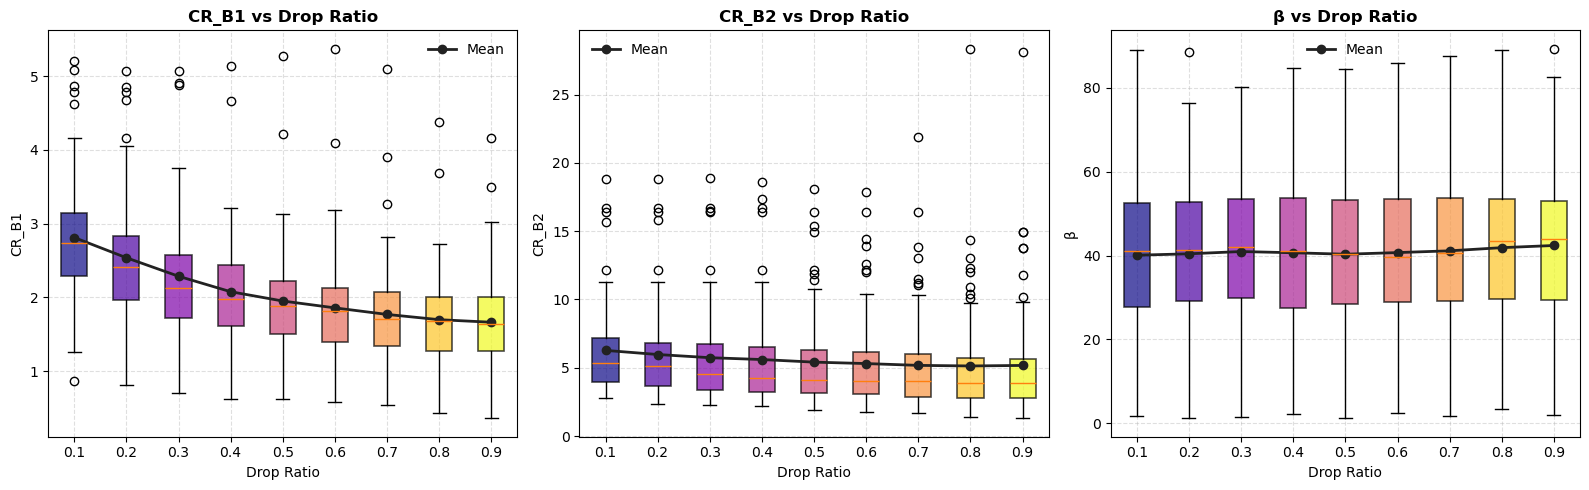

In [7]:


# === 输入主目录 ===
#base_dir = r"D:\github\Phd_summary\3_Result\2_Nagahama\1_Centerline\2_Siphon information\3_Siphon_Geometry(different drop)"
base_dir = r"D:\github\Phd_summary\3_Result\1_Brava\1_Centerline\2_Siphon information\3_Siphon_Geometry(different drop)"

# === 读取所有 drop_ratio 的结果 ===
dfs = []
for fname in sorted(os.listdir(base_dir)):
    if fname.endswith(".xlsx") and "Siphon_Geometry" in fname:
        drop_str = fname.split("drop=")[1].split(")")[0]
        drop_ratio = float(drop_str)
        df = pd.read_excel(os.path.join(base_dir, fname))
        df["drop_ratio"] = drop_ratio
        dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# === 三个参数 ===
params = ["CR_B1", "CR_B2", "β"]

# === 可视化 (箱型图 + 均值连线) ===
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = cm.get_cmap('plasma', len(df_all["drop_ratio"].unique()))  # 使用 plasma 渐变色

for ax, param in zip(axes, params):
    # 按 drop_ratio 分组
    unique_ratios = sorted(df_all["drop_ratio"].unique())
    data = [df_all[df_all["drop_ratio"] == dr][param].dropna() for dr in unique_ratios]
    labels = [f"{dr:.1f}" for dr in unique_ratios]

    # === 彩色箱型图 ===
    bp = ax.boxplot(data, tick_labels=labels, patch_artist=True)
    for patch, dr in zip(bp['boxes'], unique_ratios):
        patch.set(facecolor=colors(dr), alpha=0.7, linewidth=1.2)

    # 添加均值曲线
    means = [d.mean() for d in data]
    ax.plot(range(1, len(labels)+1), means, marker="o", color="#222222", linewidth=2, label="Mean")

    # 轴与标题
    ax.set_title(f"{param} vs Drop Ratio", fontsize=12, fontweight='bold')
    ax.set_xlabel("Drop Ratio")
    ax.set_ylabel(param)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()


### 1.6 计算每条线每个弯的最优下降率

In [8]:
# === 输入与输出路径 ===
base_dir = r"D:\github\Phd_summary\3_Result\2_Nagahama\1_Centerline\2_Siphon information\3_Siphon_Geometry(different drop)"
output_excel = r"D:\github\Phd_summary\3_Result\2_Nagahama\1_Centerline\2_Siphon information\4_Siphon_Geometry_error\1_Siphon_ErrorMatrix_and_BestDrop.xlsx"  # ← 你可以改成任意想保存的位置

# === Step 1: 读取所有不同下降率结果 ===
dfs = []
for fname in sorted(os.listdir(base_dir)):
    if fname.endswith(".xlsx") and "Siphon_Geometry" in fname:
        drop_str = fname.split("drop=")[1].split(")")[0]
        drop_ratio = float(drop_str)
        df = pd.read_excel(os.path.join(base_dir, fname))
        df["drop_ratio"] = drop_ratio
        dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
#print(f"✅ 已读取 {len(dfs)} 组下降率结果，共 {df_all.shape[0]} 条记录")

# === Step 2: 计算误差（取 4 位小数）===
df_all["inv_CR_B1"] = 1 / df_all["CR_B1"]
df_all["inv_CR_B2"] = 1 / df_all["CR_B2"]

df_all["Error_B1"] = abs(df_all["inv_CR_B1"] - df_all["𝜅_B1"]).round(4)
df_all["Error_B2"] = abs(df_all["inv_CR_B2"] - df_all["𝜅_B2"]).round(4)

# === Step 3: 构建误差矩阵（每条线每个下降率） ===
pivot_b1 = df_all.pivot_table(
    index=["Filename", "𝜅_B1"],
    columns="drop_ratio",
    values="Error_B1"
).add_prefix("Drop=").add_suffix("_B1")

pivot_b2 = df_all.pivot_table(
    index=["Filename", "𝜅_B2"],
    columns="drop_ratio",
    values="Error_B2"
).add_prefix("Drop=").add_suffix("_B2")

# 合并两个矩阵
df_error = pivot_b1.merge(pivot_b2, left_index=True, right_index=True, how="outer").reset_index()

# === Step 4: 找出每条线的最优下降率 ===
best_b1 = (
    df_all.loc[df_all.groupby("Filename")["Error_B1"].idxmin(), ["Filename", "drop_ratio", "Error_B1"]]
    .rename(columns={"drop_ratio": "Best_Drop_B1", "Error_B1": "Min_Error_B1"})
)
best_b2 = (
    df_all.loc[df_all.groupby("Filename")["Error_B2"].idxmin(), ["Filename", "drop_ratio", "Error_B2"]]
    .rename(columns={"drop_ratio": "Best_Drop_B2", "Error_B2": "Min_Error_B2"})
)

# === Step 5: 合并最优结果 ===
df_final = (
    df_error
    .merge(best_b1, on="Filename", how="left")
    .merge(best_b2, on="Filename", how="left")
)

# === Step 6: 输出 ===
df_final = df_final.sort_values("Filename")
df_final.to_excel(output_excel, index=False, float_format="%.4f")

#print(f"✅ 已保存完整结果：{output_excel}")


=== B1 最优下降率分布 ===
Best_Drop_B1
0.3     1
0.4     2
0.5     7
0.6     6
0.7    17
0.8    20
0.9    25
Name: count, dtype: int64

=== B2 最优下降率分布 ===
Best_Drop_B2
0.1     5
0.2     1
0.3     4
0.4     5
0.5     9
0.6     8
0.7     8
0.8    14
0.9    24
Name: count, dtype: int64

=== Overall (B1 + B2) 最优下降率分布 ===
0.1     5
0.2     1
0.3     5
0.4     7
0.5    16
0.6    14
0.7    25
0.8    34
0.9    49
Name: count, dtype: int64


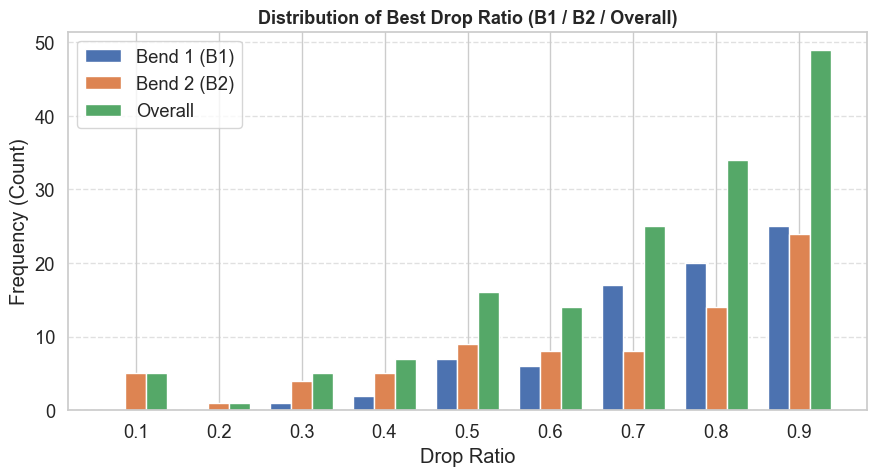

In [37]:
# === 输入文件 ===
input_excel = r"D:\github\Phd_summary\3_Result\1_Brava\1_Centerline\2_Siphon information\4_Siphon_Geometry_error\1_Siphon_ErrorMatrix_and_BestDrop.xlsx"

# === 读取数据 ===
df = pd.read_excel(input_excel)

# === 提取 B1 / B2 的最优下降率 ===
b1_drops = df["Best_Drop_B1"].dropna().round(1)
b2_drops = df["Best_Drop_B2"].dropna().round(1)

# === 统计频率 ===
b1_counts = b1_drops.value_counts().sort_index()
b2_counts = b2_drops.value_counts().sort_index()

# === 计算整体分布（B1 + B2 合并）===
all_drops = pd.concat([b1_drops, b2_drops])
all_counts = all_drops.value_counts().sort_index()

print("=== B1 最优下降率分布 ===")
print(b1_counts)
print("\n=== B2 最优下降率分布 ===")
print(b2_counts)
print("\n=== Overall (B1 + B2) 最优下降率分布 ===")
print(all_counts)

# === 合并成 DataFrame 便于绘图 ===
drop_levels = sorted(set(b1_counts.index).union(b2_counts.index))
freq_df = pd.DataFrame({
    "Drop_Ratio": drop_levels,
    "B1_Count": [b1_counts.get(x, 0) for x in drop_levels],
    "B2_Count": [b2_counts.get(x, 0) for x in drop_levels],
    "All_Count": [all_counts.get(x, 0) for x in drop_levels]
})

# === 可视化：柱状对比图（B1/B2 + Overall）===
plt.figure(figsize=(9, 5))
bar_width = 0.25
x = range(len(freq_df))

plt.bar([i - bar_width for i in x], freq_df["B1_Count"], width=bar_width, color="#4C72B0", label="Bend 1 (B1)")
plt.bar(x, freq_df["B2_Count"], width=bar_width, color="#DD8452", label="Bend 2 (B2)")
plt.bar([i + bar_width for i in x], freq_df["All_Count"], width=bar_width, color="#55A868", label="Overall")

plt.xticks(x, [f"{v:.1f}" for v in freq_df["Drop_Ratio"]])
plt.xlabel("Drop Ratio")
plt.ylabel("Frequency (Count)")
plt.title("Distribution of Best Drop Ratio (B1 / B2 / Overall)", fontsize=13, fontweight="bold")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()

plt.show()


### 1.7 最大曲率和最优曲率下降率的散点图

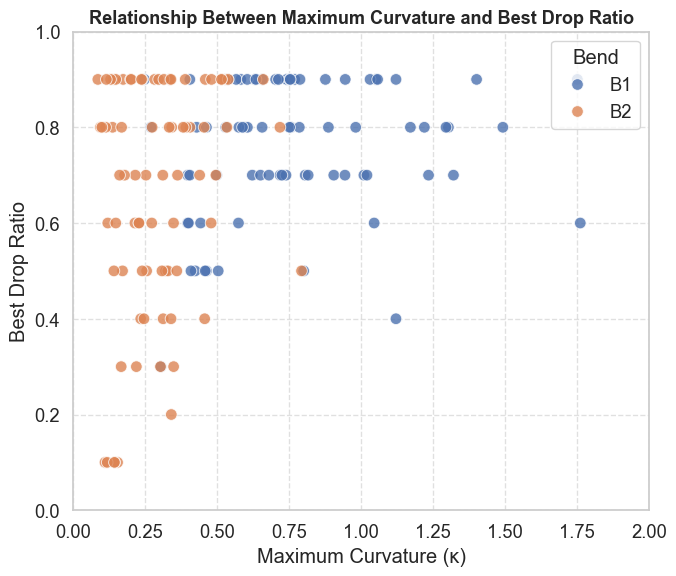

In [36]:
# === 输入文件 ===
input_excel = r"D:\github\Phd_summary\3_Result\1_Brava\1_Centerline\2_Siphon information\4_Siphon_Geometry_error\1_Siphon_ErrorMatrix_and_BestDrop.xlsx"

# === 读取数据 ===
df = pd.read_excel(input_excel)

# 去除缺失值
df_b1 = df[["𝜅_B1", "Best_Drop_B1"]].dropna().rename(columns={"𝜅_B1": "Curvature", "Best_Drop_B1": "Best_Drop"})
df_b1["Bend"] = "B1"

df_b2 = df[["𝜅_B2", "Best_Drop_B2"]].dropna().rename(columns={"𝜅_B2": "Curvature", "Best_Drop_B2": "Best_Drop"})
df_b2["Bend"] = "B2"

# 合并数据
df_all = pd.concat([df_b1, df_b2], ignore_index=True)

# === 坐标范围（可自定义）===
xlim = (0, 2.0)      # 最大曲率范围
ylim = (0.0, 1.0)    # 最优下降率范围

# === 绘图 ===
sns.set(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(7, 6))

sns.scatterplot(
    data=df_all, x="Curvature", y="Best_Drop",
    hue="Bend", palette={"B1": "#4C72B0", "B2": "#DD8452"},
    s=70, alpha=0.8, edgecolor="white"
)

plt.xlabel("Maximum Curvature (κ)")
plt.ylabel("Best Drop Ratio")
plt.xlim(xlim)
plt.ylim(ylim)
plt.title("Relationship Between Maximum Curvature and Best Drop Ratio", fontsize=13, fontweight='bold')
plt.legend(title="Bend", loc="upper right", frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# === 保存图像 ===
#output_fig = input_excel.replace(".xlsx", "_Combined_Curvature_vs_BestDrop.png")
#plt.savefig(output_fig, dpi=300, bbox_inches="tight")
plt.show()

#print(f"✅ 图像已保存：{output_fig}")


### 1.8 基于最优下降率的形状抽取

In [10]:
import os
import numpy as np
import pandas as pd
import pyvista as pv
from sklearn.decomposition import PCA

# =====================
# 基础函数定义
# =====================

def extract_adaptive_segment_value(pts, curv, drop_ratio):
    """根据曲率下降比例截取局部弯段"""
    max_idx = np.argmax(curv)
    max_val = curv[max_idx]
    left_idx, right_idx = max_idx, max_idx
    while left_idx > 0 and curv[left_idx] > drop_ratio * max_val:
        left_idx -= 1
    while right_idx < len(curv) - 1 and curv[right_idx] > drop_ratio * max_val:
        right_idx += 1
    seg_pts = pts[left_idx:right_idx + 1]
    return seg_pts, max_val, left_idx, right_idx


def fit_circle_3d(pts):
    """PCA降维到2D平面 → 拟合圆 → 还原3D空间"""
    pca = PCA(n_components=2)
    mean = pts.mean(axis=0)
    pts_centered = pts - mean
    pca.fit(pts_centered)
    basis = pca.components_
    proj_2d = pts_centered @ basis.T
    x, y = proj_2d[:, 0], proj_2d[:, 1]
    A = np.c_[2*x, 2*y, np.ones_like(x)]
    b = x**2 + y**2
    cx, cy, c = np.linalg.lstsq(A, b, rcond=None)[0]
    r = np.sqrt(c + cx**2 + cy**2)
    center_3d = mean + basis.T @ np.array([cx, cy])
    normal = np.cross(basis[0], basis[1])
    return r, center_3d, normal


def angle_deg_between(v1, v2):
    """两个向量的夹角（度）"""
    cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    return np.degrees(np.arccos(cos_theta))


# =====================
# 主程序：基于最优下降率重新提取参数
# =====================

# 输入路径
vtk_dir = r"D:\github\Phd_summary\1_Data\2_Nagahama\1_Centerline\8_siphon_with_label"
best_drop_excel = r"D:\github\Phd_summary\3_Result\2_Nagahama\1_Centerline\2_Siphon information\4_Siphon_Geometry_error\1_Siphon_ErrorMatrix_and_BestDrop.xlsx"
output_excel = r"D:\github\Phd_summary\3_Result\2_Nagahama\1_Centerline\2_Siphon information\5_Siphon_Geometry_BestDrop.xlsx"

#vtk_dir = r"D:\github\Phd_summary\1_Data\1_Brava\1_Centerline\8_Centerline_Siphon(with labal)"
#best_drop_excel = r"D:\github\Phd_summary\3_Result\1_Brava\1_Centerline\2_Siphon information\4_Siphon_Geometry_error\1_Siphon_ErrorMatrix_and_BestDrop.xlsx"
#output_excel = r"D:\github\Phd_summary\3_Result\1_Brava\1_Centerline\2_Siphon information\5_Siphon_Geometry_BestDrop.xlsx"



# 读取最优下降率表
df_best = pd.read_excel(best_drop_excel)

results = []

for _, row in df_best.iterrows():
    fname = f"{row['Filename']}.vtk"
    best_drop_b1 = row["Best_Drop_B1"]
    best_drop_b2 = row["Best_Drop_B2"]

    fpath = os.path.join(vtk_dir, fname)
    if not os.path.exists(fpath):
        print(f"⚠️ 跳过：未找到 {fname}")
        continue

    try:
        centerline = pv.read(fpath)
        points = centerline.points
        curvature = centerline["curvature"]
        labels = centerline["lab"]

        # === B1 ===
        bend1_pts = points[labels == 1]
        bend1_curv = curvature[labels == 1]
        seg1, _, _, _ = extract_adaptive_segment_value(bend1_pts, bend1_curv, best_drop_b1)
        r1, center1, normal1 = fit_circle_3d(seg1)

        # === B2 ===
        bend2_pts = points[labels == 2]
        bend2_curv = curvature[labels == 2]
        seg2, _, _, _ = extract_adaptive_segment_value(bend2_pts, bend2_curv, best_drop_b2)
        r2, center2, normal2 = fit_circle_3d(seg2)

        # === β角 ===
        beta = angle_deg_between(normal1, normal2)
        if beta > 90:
            beta = 180 - beta

        results.append({
            "Filename": row["Filename"],
            "Best_Drop_B1": best_drop_b1,
            "Best_Drop_B2": best_drop_b2,
            "CR_B1": round(r1, 4),
            "CR_B2": round(r2, 4),
            "β": round(beta, 2)
        })

    except Exception as e:
        print(f"Error in {fname}: {e}")

# 汇总输出
df_result = pd.DataFrame(results)
df_result.to_excel(output_excel, index=False)
print(f"✅ 已输出结果到：{output_excel}")


✅ 已输出结果到：D:\github\Phd_summary\3_Result\2_Nagahama\1_Centerline\2_Siphon information\5_Siphon_Geometry_BestDrop.xlsx


### 1.9 抽取后形状分布（箱图）


--- CR_B1 ---
Q1    : 2.5819
Median: 3.0283
Q3    : 3.7204

--- CR_B2 ---
Q1    : 3.2385
Median: 4.1256
Q3    : 6.3047

--- β ---
Q1    : 36.6600
Median: 51.3100
Q3    : 65.7550


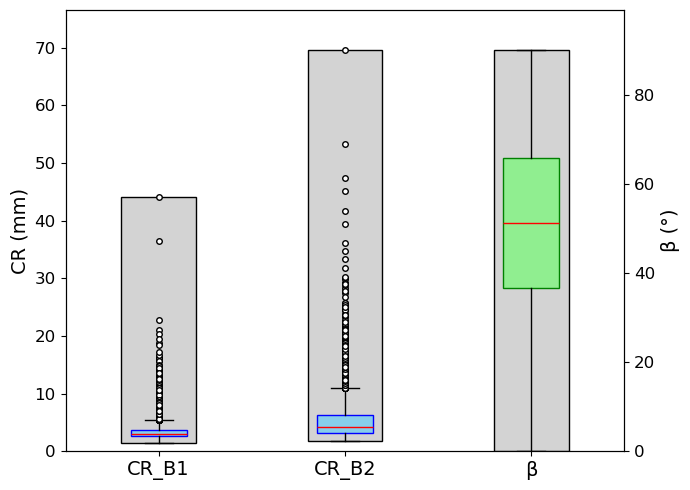

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# === 读取数据 ===
file_path = r"D:\github\Phd_summary\3_Result\2_Nagahama\1_Centerline\2_Siphon information\5_Siphon_Geometry_BestDrop_eidt.xlsx"
#file_path = r"D:\github\Phd_summary\3_Result\1_Brava\1_Centerline\2_Siphon information\5_Siphon_Geometry_BestDrop.xlsx"

df = pd.read_excel(file_path)

# === 重命名列，避免符号混乱 ===
df = df.rename(columns={
    "CR_B1": "CR_B1",
    "CR_B2": "CR_B2",
    "β": "β"
})

# === 打印 Q1, Median, Q3 ===
summary_stats = {}
for col in ["CR_B1", "CR_B2", "β"]:
    q1 = df[col].quantile(0.25)
    q2 = df[col].quantile(0.50)
    q3 = df[col].quantile(0.75)
    summary_stats[col] = {"Q1": q1, "Median": q2, "Q3": q3}

for col, stats in summary_stats.items():
    print(f"\n--- {col} ---")
    print(f"Q1    : {stats['Q1']:.4f}")
    print(f"Median: {stats['Median']:.4f}")
    print(f"Q3    : {stats['Q3']:.4f}")

# === 创建图形 ===
fig, ax1 = plt.subplots(figsize=(7, 5))

# === 主坐标轴：CR_B1 / CR_B2 ===
cr_b1_min, cr_b1_max = df["CR_B1"].min(), df["CR_B1"].max()
cr_b2_min, cr_b2_max = df["CR_B2"].min(), df["CR_B2"].max()
bar_heights = [cr_b1_max - cr_b1_min, cr_b2_max - cr_b2_min]
bar_positions = [0, 1]
bar_bottoms = [cr_b1_min, cr_b2_min]

# 条形灰色范围背景
ax1.bar(bar_positions, bar_heights, bottom=bar_bottoms, width=0.4,
        color='lightgray', edgecolor='black', label='CR Range')

# 箱线图（蓝）
ax1.boxplot([df["CR_B1"], df["CR_B2"]],
            positions=bar_positions, widths=0.3, patch_artist=True,
            boxprops=dict(facecolor="skyblue", color="blue"),
            medianprops=dict(color="red"),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black"),
            flierprops=dict(marker='o', markersize=4, markerfacecolor="white", markeredgecolor="black"))

ax1.set_ylabel("CR (mm)", fontsize=14)
ax1.set_ylim(0, max(cr_b1_max, cr_b2_max) * 1.1)
ax1.tick_params(axis='y', labelsize=12)

# === 右轴：β ===
ax2 = ax1.twinx()
beta_min, beta_max = df["β"].min(), df["β"].max()
beta_height = beta_max - beta_min
beta_position = 2

# β灰色条
ax2.bar(beta_position, beta_height, bottom=beta_min, width=0.4,
        color='lightgray', edgecolor='black', label='Beta Range')

# β箱线图（绿）
ax2.boxplot([df["β"]], positions=[beta_position], widths=0.3, patch_artist=True,
            boxprops=dict(facecolor="lightgreen", color="green"),
            medianprops=dict(color="red"),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black"),
            flierprops=dict(marker='o', markersize=4, markerfacecolor="white", markeredgecolor="black"))

ax2.set_ylabel("β (°)", fontsize=14)
ax2.set_ylim(0, beta_max * 1.1)
ax2.tick_params(axis='y', labelsize=12)

# === X轴 ===
ax1.set_xticks([0, 1, 2])
ax1.set_xticklabels(["CR_B1", "CR_B2", "β"], fontsize=14)
ax1.grid(False)
ax2.grid(False)

# === 图整体格式 ===
fig.patch.set_facecolor('white')
ax1.set_facecolor('white')
ax2.set_facecolor('white')

plt.tight_layout()
plt.show()


## 2 形状分类

### 2.1 分类机制 

In [34]:
# === 输入与输出路径 ===
input_path = r"D:\github\Phd_summary\3_Result\2_Nagahama\1_Centerline\2_Siphon information\5_Siphon_Geometry_BestDrop_eidt.xlsx"
output_dir = r"D:\github\Phd_summary\3_Result\2_Nagahama\1_Centerline\3_Classification"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "classified_centerlines_BestDrop.csv")

# === 读取数据 ===
df = pd.read_excel(input_path)

# === 列名清理（防止特殊符号）===
df = df.rename(columns={"𝛽": "β", "Β": "β"})

# === 阈值设定（可根据Q3或中位数修改）===
cr_b1_threshold = 2.5819
cr_b2_threshold = 3.2385
beta_threshold = 65.7550

#cr_b1_threshold = 1.3039
#cr_b2_threshold = 3.0484
#beta_threshold = 53.7350

# === 分类函数 ===
def classify_siphon(row):
    cr_b1 = row["CR_B1"]
    cr_b2 = row["CR_B2"]
    beta = row["β"]

    if cr_b1 > cr_b1_threshold:
        return "U"
    elif cr_b1 <= cr_b1_threshold and cr_b2 <= cr_b2_threshold:
        return "S"
    elif cr_b1 <= cr_b1_threshold and cr_b2 > cr_b2_threshold and beta <= beta_threshold:
        return "V"
    elif cr_b1 <= cr_b1_threshold and cr_b2 > cr_b2_threshold and beta > beta_threshold:
        return "C"
    else:
        return "Unclassified"

# === 应用分类 ===
df["Type"] = df.apply(classify_siphon, axis=1)

# === 输出所需列 ===
df_output = df[["Filename", "CR_B1", "CR_B2", "β", "Type"]]

# === 保存结果 ===
df_output.to_csv(output_path, index=False, encoding="utf-8-sig")
print(f"✅ 分类完成，结果已保存至：\n{output_path}")
print(df_output.head())


✅ 分类完成，结果已保存至：
D:\github\Phd_summary\3_Result\2_Nagahama\1_Centerline\3_Classification\classified_centerlines_BestDrop.csv
                                            Filename   CR_B1    CR_B2      β  \
0  00000000.nii_L_ICA_labeled_resampled0.3_siphon...  3.4011   2.6088  27.37   
1  00000001.nii_L_ICA_labeled_resampled0.3_siphon...  2.7273   3.2191  86.38   
2  00000001.nii_R_ICA_labeled_resampled0.3_siphon...  2.6824   3.3932  64.28   
3  00000003.nii_R_ICA_labeled_resampled0.3_siphon...  3.0555  20.2015  79.72   
4  00000004.nii_L_ICA_labeled_resampled0.3_siphon...  2.8724   9.1955  85.57   

  Type  
0    U  
1    U  
2    U  
3    U  
4    U  


### 2.2 分类可视化

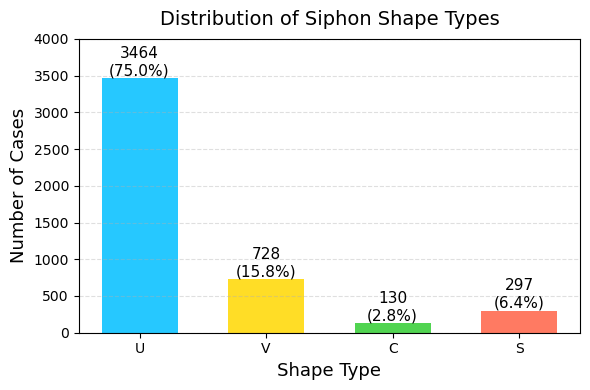

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# === 读取数据 ===
file_path = r"D:\github\Phd_summary\3_Result\2_Nagahama\1_Centerline\3_Classification\classified_centerlines_BestDrop.csv"
df = pd.read_csv(file_path)

# === 固定顺序与颜色 ===
order = ["U", "V", "C", "S"]
colors = ["deepskyblue", "gold", "limegreen", "tomato"]

# === 统计并按顺序排列 ===
summary = df["Type"].value_counts().reindex(order, fill_value=0)
percent = (summary / summary.sum() * 100).round(1)

# === 绘图 ===
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(order, summary.values, color=colors, alpha=0.85, width=0.6)

# === 添加数值与占比 ===
for bar, pct in zip(bars, percent):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 1.5,
            f"{int(height)}\n({pct:.1f}%)",
            ha='center', va='bottom', fontsize=11)

# === 轴与样式 ===
ax.set_xlabel("Shape Type", fontsize=13)
ax.set_ylabel("Number of Cases", fontsize=13)
ax.set_title("Distribution of Siphon Shape Types", fontsize=14, pad=10)
ax.set_ylim(0, 4000)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.show()


### 2.2 形状参数分布

<Figure size 1000x400 with 0 Axes>

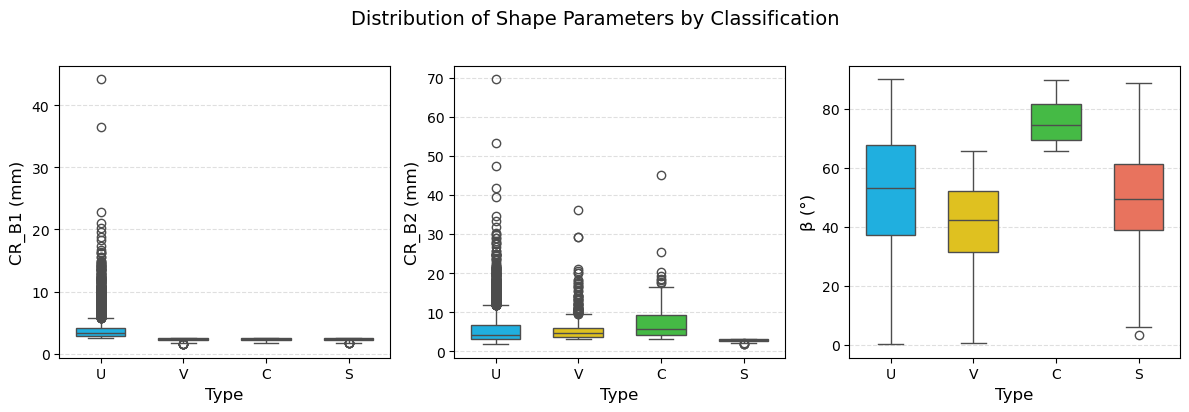

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === 读取数据 ===
file_path = r"D:\github\Phd_summary\3_Result\2_Nagahama\1_Centerline\3_Classification\classified_centerlines_BestDrop.csv"
df = pd.read_csv(file_path)

# === 设定颜色与顺序 ===
order = ["U", "V", "C", "S"]
palette = ["deepskyblue", "gold", "limegreen", "tomato"]

# === 图形设置 ===
plt.figure(figsize=(10, 4))
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'

# === 子图布局：三个参数并列 ===
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=False, sharey=False)

params = ["CR_B1", "CR_B2", "β"]
ylabels = ["CR_B1 (mm)", "CR_B2 (mm)", "β (°)"]

for i, (param, ylabel) in enumerate(zip(params, ylabels)):
    sns.boxplot(data=df, x="Type", y=param,
                order=order, palette=palette,
                width=0.6, ax=axes[i])
    
    # 美化
    axes[i].set_xlabel("Type", fontsize=12)
    axes[i].set_ylabel(ylabel, fontsize=12)
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)
    axes[i].set_facecolor('white')

# === 整体标题 ===
fig.suptitle("Distribution of Shape Parameters by Classification", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
drop_ratios = np.linspace(0.1, 0.9, 9)
cr_b1_list, cr_b2_list, beta_list = [], [], []

for dr in drop_ratios:
    # === B1 ===
    seg1, max_curv1, left1, right1 = extract_adaptive_segment_value(bend1_pts, bend1_curv, drop_ratio=dr)
    _, _, r1, _, _, normal1 = fit_circle_3d(seg1)
    tan1_out = -get_tangent(bend1_pts, right1)

    # === B2 ===
    seg2, max_curv2, left2, right2 = extract_adaptive_segment_value(bend2_pts, bend2_curv, drop_ratio=dr)
    _, _, r2, _, _, normal2 = fit_circle_3d(seg2)
    tan2_in = -get_tangent(bend2_pts, left2)

    # === 法向量夹角 β (0~90°) ===
    beta_angle = angle_deg_between(normal1, normal2)
    if beta_angle > 90:
        beta_angle = 180 - beta_angle

    cr_b1_list.append(r1)
    cr_b2_list.append(r2)
    beta_list.append(beta_angle)

# 计算平均值
mean_cr_b1 = np.mean(cr_b1_list)
mean_cr_b2 = np.mean(cr_b2_list)
mean_beta = np.mean(beta_list)

# === 1x3子图 ===
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# --- 第1个子图 CR_B1 ---
axes[0].plot(drop_ratios, cr_b1_list, 'o-', color='blue', label='CR_B1')
axes[0].axhline(y=mean_cr_b1, color='blue', linestyle='--', label=f'Mean={mean_cr_b1:.2f}')
axes[0].set_xlabel('Curvature drop ratio')
axes[0].set_ylabel('CR_B1')
axes[0].set_title('CR_B1 vs drop ratio')
axes[0].grid(True)
axes[0].legend()

# --- 第2个子图 CR_B2 ---
axes[1].plot(drop_ratios, cr_b2_list, 's-', color='green', label='CR_B2')
axes[1].axhline(y=mean_cr_b2, color='green', linestyle='--', label=f'Mean={mean_cr_b2:.2f}')
axes[1].set_xlabel('Curvature drop ratio')
axes[1].set_ylabel('CR_B2')
axes[1].set_title('CR_B2 vs drop ratio')
axes[1].grid(True)
axes[1].legend()

# --- 第3个子图 β ---
axes[2].plot(drop_ratios, beta_list, '^-', color='red', label='β angle')
axes[2].axhline(y=mean_beta, color='red', linestyle='--', label=f'Mean={mean_beta:.2f}')
axes[2].set_xlabel('Curvature drop ratio')
axes[2].set_ylabel('β angle (deg)')
axes[2].set_title('β angle vs drop ratio')
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 确保 DropRatio 是分类变量，这样每个值就是一个分组
df_long['DropRatio'] = df_long['DropRatio'].astype(str)  # 转成字符串分类，这样顺序在箱线图上固定

plt.figure(figsize=(6,4))
sns.boxplot(x='DropRatio', y='CR_B1', data=df_long, palette='Set2')
plt.title('CR_B1 Distribution by Drop Ratio')
plt.xlabel('Curvature drop ratio')
plt.ylabel('CR_B1')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='DropRatio', y='CR_B2', data=df_long, palette='Set2')
plt.title('CR_B2 Distribution by Drop Ratio')
plt.xlabel('Curvature drop ratio')
plt.ylabel('CR_B2')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='DropRatio', y='Beta', data=df_long, palette='Set2')
plt.title('β angle Distribution by Drop Ratio')
plt.xlabel('Curvature drop ratio')
plt.ylabel('β angle (deg)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 确保 DropRatio 是分类变量，这样每个值就是一个分组
df_long['DropRatio'] = df_long['DropRatio'].astype(str)  # 转成字符串分类，这样顺序在箱线图上固定

plt.figure(figsize=(6,4))
sns.boxplot(x='DropRatio', y='CR_B1', data=df_long, palette='Set2')
plt.title('CR_B1 Distribution by Drop Ratio')
plt.xlabel('Curvature drop ratio')
plt.ylabel('CR_B1')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='DropRatio', y='CR_B2', data=df_long, palette='Set2')
plt.title('CR_B2 Distribution by Drop Ratio')
plt.xlabel('Curvature drop ratio')
plt.ylabel('CR_B2')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='DropRatio', y='Beta', data=df_long, palette='Set2')
plt.title('β angle Distribution by Drop Ratio')
plt.xlabel('Curvature drop ratio')
plt.ylabel('β angle (deg)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [8]:
import os
import numpy as np
import pandas as pd
import pyvista as pv
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from sklearn.decomposition import PCA

# === 输入路径 ===
vtk_dir = r"D:\github\Phd_summary\1_Data\1_Brava\1_Centerline\8_Centerline_Siphon(with labal)"
excel_path = r"D:\github\Phd_summary\3_Result\1_Brava\1_Centerline\2_Siphon information\4_Siphon_Geometry_error\1_Siphon_ErrorMatrix_and_BestDrop.xlsx"
save_pdf = r"D:\github\Phd_summary\3_Result\1_Brava\1_Centerline\2_Siphon information\2_Siphon_Geometry_BestDrop.pdf"

# === 参数设定 ===
PLANE_SIZE = 5.0
TANGENT_SCALE = 2.0

# === 读取 Excel ===
drop_df = pd.read_excel(excel_path)
drop_df["Filename"] = drop_df["Filename"].astype(str)

# === 函数定义 ===
def extract_adaptive_segment(pts, curv, drop_ratio=0.5):
    max_idx = np.argmax(curv)
    max_val = curv[max_idx]
    left_idx, right_idx = max_idx, max_idx
    while left_idx > 0 and curv[left_idx] > drop_ratio * max_val:
        left_idx -= 1
    while right_idx < len(curv) - 1 and curv[right_idx] > drop_ratio * max_val:
        right_idx += 1
    seg_pts = pts[left_idx:right_idx + 1]
    max_pt = pts[max_idx]
    return seg_pts, max_pt, left_idx, right_idx

def fit_circle_3d(pts):
    pca = PCA(n_components=2)
    mean = pts.mean(axis=0)
    pts_centered = pts - mean
    pca.fit(pts_centered)
    basis = pca.components_
    proj_2d = pts_centered @ basis.T
    x, y = proj_2d[:, 0], proj_2d[:, 1]
    A = np.c_[2*x, 2*y, np.ones_like(x)]
    b = x**2 + y**2
    cx, cy, c = np.linalg.lstsq(A, b, rcond=None)[0]
    r = np.sqrt(c + cx**2 + cy**2)
    theta = np.linspace(0, 2*np.pi, 100)
    circle_2d = np.c_[r*np.cos(theta)+cx, r*np.sin(theta)+cy]
    circle_3d = circle_2d @ basis + mean
    center_3d = mean + basis.T @ np.array([cx, cy])
    normal = np.cross(basis[0], basis[1])
    return circle_3d, center_3d, r, mean, basis, normal

def get_tangent(pts, idx):
    if idx <= 0:
        return pts[idx + 1] - pts[idx]
    elif idx >= len(pts) - 1:
        return pts[idx] - pts[idx - 1]
    else:
        return pts[idx + 1] - pts[idx - 1]

def draw_arrow(ax, start, vec, proj, color, label=None):
    idx_map = {"xy": (0, 1), "xz": (0, 2), "yz": (1, 2)}
    i, j = idx_map[proj]
    ax.quiver(start[i], start[j], vec[i], vec[j], angles='xy', scale_units='xy',
              scale=1 / TANGENT_SCALE, color=color, label=label)
    ax.plot(start[i], start[j], marker='o', color='white',
            markeredgecolor=color, markersize=4, markeredgewidth=1.2)

def draw_plane(ax, center, basis, proj, size=PLANE_SIZE, color='gray', alpha=0.25):
    u, v = basis
    corners = np.array([
        center + size * u + size * v,
        center - size * u + size * v,
        center - size * u - size * v,
        center + size * u - size * v
    ])
    idx_map = {"xy": (0, 1), "xz": (0, 2), "yz": (1, 2)}
    i, j = idx_map[proj]
    polygon_pts = corners[:, [i, j]]
    polygon = Polygon(polygon_pts, color=color, alpha=alpha)
    ax.add_patch(polygon)

# === 主绘制 ===
vtk_files = sorted([f for f in os.listdir(vtk_dir) if f.endswith(".vtk")])
n = len(vtk_files)
projections = ['xy', 'xz', 'yz']
idx_map = {"xy": (0, 1), "xz": (0, 2), "yz": (1, 2)}

# === PDF 输出 ===
from matplotlib.backends.backend_pdf import PdfPages
with PdfPages(save_pdf) as pdf:
    for row_idx, fname in enumerate(vtk_files):
        fpath = os.path.join(vtk_dir, fname)
        base = os.path.splitext(fname)[0]

        match = drop_df[drop_df["Filename"].str.contains(base, case=False, regex=False)]
        if match.empty:
            print(f"⚠️ 未找到匹配项: {fname}")
            continue

        best_drop_b1 = float(match["Best_Drop_B1"].values[0])
        best_drop_b2 = float(match["Best_Drop_B2"].values[0])

        centerline = pv.read(fpath)
        if not all(k in centerline.point_data for k in ["curvature", "lab"]):
            continue

        points = centerline.points
        curvature = centerline["curvature"]
        labels = centerline["lab"]

        # === Bend 1 ===
        bend1_pts = points[labels == 1]
        bend1_curv = curvature[labels == 1]
        seg1, kmax1, left1, right1 = extract_adaptive_segment(bend1_pts, bend1_curv, drop_ratio=best_drop_b1)
        circle1, center1, r1, origin1, basis1, normal1 = fit_circle_3d(seg1)
        tan1_in = -get_tangent(bend1_pts, left1)
        tan1_out = -get_tangent(bend1_pts, right1)

        # === Bend 2 ===
        bend2_pts = points[labels == 2]
        bend2_curv = curvature[labels == 2]
        seg2, kmax2, left2, right2 = extract_adaptive_segment(bend2_pts, bend2_curv, drop_ratio=best_drop_b2)
        circle2, center2, r2, origin2, basis2, normal2 = fit_circle_3d(seg2)
        tan2_in = -get_tangent(bend2_pts, left2)
        tan2_out = -get_tangent(bend2_pts, right2)

        # === 绘图 ===
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        for col_idx, proj in enumerate(projections):
            ax = axes[col_idx]
            i, j = idx_map[proj]
            ax.plot(points[:, i], points[:, j], 'k-', label='Centerline')
            ax.plot(circle1[:, i], circle1[:, j], 'b--', label='Circle 1')
            ax.plot(circle2[:, i], circle2[:, j], 'r--', label='Circle 2')
            ax.plot(kmax1[i], kmax1[j], 'co', label='Max Curv 1')
            ax.plot(kmax2[i], kmax2[j], 'mo', label='Max Curv 2')

            draw_arrow(ax, center1, normal1, proj, 'blue', 'Normal 1')
            draw_arrow(ax, center2, normal2, proj, 'red', 'Normal 2')
            draw_arrow(ax, bend1_pts[left1], tan1_in, proj, 'cyan', 'Bend1 In')
            draw_arrow(ax, bend1_pts[right1], tan1_out, proj, 'dodgerblue', 'Bend1 Out')
            draw_arrow(ax, bend2_pts[left2], tan2_in, proj, 'orange', 'Bend2 In')
            draw_arrow(ax, bend2_pts[right2], tan2_out, proj, 'tomato', 'Bend2 Out')

            draw_plane(ax, center1, basis1, proj, color='blue')
            draw_plane(ax, center2, basis2, proj, color='red')
            ax.set_title(f"{base} ({proj.upper()})\nB1={best_drop_b1:.2f}, B2={best_drop_b2:.2f}")
            ax.set_box_aspect(1)
            ax.grid(True)

            if proj == 'yz':
                handles, labels_ = ax.get_legend_handles_labels()
                if handles:
                    ax.legend(handles, labels_,
                        loc='lower right', fontsize=8,
                        frameon=True, borderpad=0.3, labelspacing=0.3,
                        handlelength=1.5, handletextpad=0.5,
                        borderaxespad=0.5, framealpha=0.6)
        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

print(f"✅ 已保存PDF：{save_pdf}")


✅ 已保存PDF：D:\github\Phd_summary\3_Result\1_Brava\1_Centerline\2_Siphon information\2_Siphon_Geometry_BestDrop.pdf


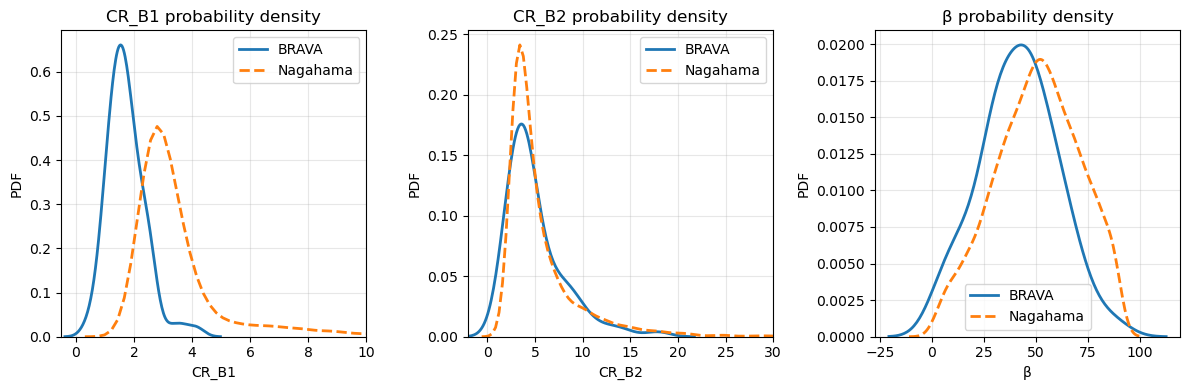

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ===== Excel 路径 =====
excel_1 = r"D:\github\Phd_summary\3_Result\1_Brava\1_Centerline\2_Siphon information\5_Siphon_Geometry_BestDrop.xlsx"
excel_2 = r"D:\github\Phd_summary\3_Result\2_Nagahama\1_Centerline\2_Siphon information\5_Siphon_Geometry_BestDrop_eidt.xlsx"

label_1 = "BRAVA"
label_2 = "Nagahama"

# ===== 读取 =====
df1 = pd.read_excel(excel_1)
df2 = pd.read_excel(excel_2)

# ===== 列 =====
cols = ["CR_B1", "CR_B2", "β"]

# ===== 手动设置横轴范围 =====
xlim_map = {
    "CR_B1": (-0.5, 10.0),   # ← 你可以按需要改
    "CR_B2": (-2, 30.0),
    # "β": (0, 180)        # β 如需也可加
}

plt.figure(figsize=(12, 4))

for i, c in enumerate(cols, 1):
    plt.subplot(1, 3, i)

    sns.kdeplot(
        df1[c].dropna(),
        linewidth=2,
        label=label_1
    )
    sns.kdeplot(
        df2[c].dropna(),
        linewidth=2,
        linestyle="--",
        label=label_2
    )

    # ===== 设置横轴范围（如果有定义）=====
    if c in xlim_map:
        plt.xlim(*xlim_map[c])

    plt.xlabel(c)
    plt.ylabel("PDF")
    plt.title(f"{c} probability density")
    plt.grid(alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()
